Inspirations / Learning tools:
[ Sentiment Analysis with BERT Neural Network and Python ](https://www.youtube.com/watch?v=szczpgOEdXs&t=1083s)

# Import data, create model

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn
from scipy.stats import chi2_contingency

In [2]:
# Choose model

model_id = "nlptown/bert-base-multilingual-uncased-sentiment"
#model_id = "tabularisai/multilingual-sentiment-analysis"

In [3]:
# Create model
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id)

In [4]:
df = pd.read_csv('data/reddit_posts.csv')
df.columns

Index(['Title', 'Political Lean', 'Score', 'Subreddit', 'Num of Comments',
       'Text', 'Date Created'],
      dtype='object')

In [5]:
df = df.rename(columns={"Title": "title", "Text": "selftext"})
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')

# Define function for sentiment analysis:

In [6]:
def sentiment_analysis(model, post_str):
    tokens = tokenizer.encode(post_str, return_tensors="pt")
    result = model(tokens)
    if int(torch.argmax(result.logits)) < 0:
        print(post_str)
    return int(torch.argmax(result.logits)) + 1

In [7]:
def chisquare_analysis(data):
    stat, p, dof, expected = chi2_contingency(data)
    return p

In [8]:
#create new column in df:
df["Sentiment"] = 0

for i in range(0, len(df)):
    df.at[i, "Sentiment"] = sentiment_analysis(model, df.iloc[i]["title"])

df.to_csv("data/reddit_posts_sentiment.csv", index=False)

# Visualisations

After performing chi2 analysis, we find a p-value of 4.0629485042714505e-09


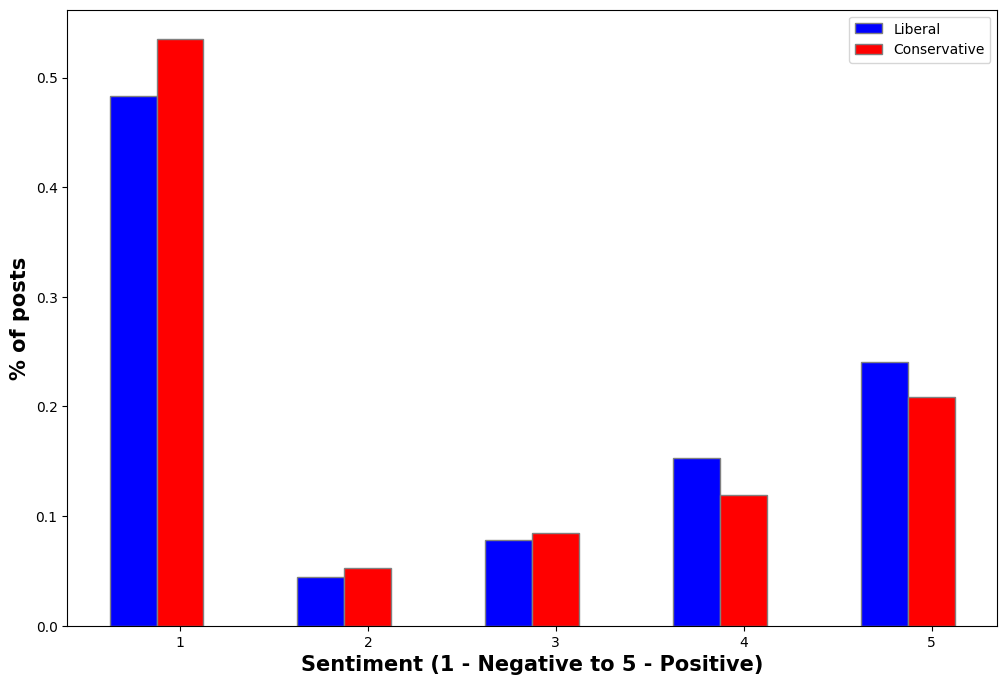

In [9]:
# Dichotomy lib / cons


num_lib_posts = df.groupby("Political Lean").size()["Liberal"]
num_cons_posts = df.groupby("Political Lean").size()["Conservative"]
sentiments_lib_cat = df[df["Political Lean"] == "Liberal"].groupby(by="Sentiment").size().to_list() 
sentiments_cons_cat = df[df["Political Lean"] == "Conservative"].groupby(by="Sentiment").size().to_list() 

# Sentiment distribution in liberal/conservative
print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis([sentiments_lib_cat, sentiments_cons_cat])}")

sentiments_lib_cat = sentiments_lib_cat / num_lib_posts
sentiments_cons_cat = sentiments_cons_cat /num_cons_posts

barWidth = 0.25
fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(sentiments_lib_cat)) 
br2 = [x + barWidth for x in br1] 

plt.bar(br1, sentiments_lib_cat, color ='b', width = barWidth, 
        edgecolor ='grey', label ='Liberal') 
plt.bar(br2, sentiments_cons_cat, color ='r', width = barWidth, 
        edgecolor ='grey', label ='Conservative')

plt.xlabel('Sentiment (1 - Negative to 5 - Positive)', fontweight ='bold', fontsize = 15) 
plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth for r in range(len(sentiments_lib_cat))], 
        ['1', '2', '3', '4', '5'])

plt.legend()
plt.show()  

After performing chi2 analysis, we find a p-value of 0.0


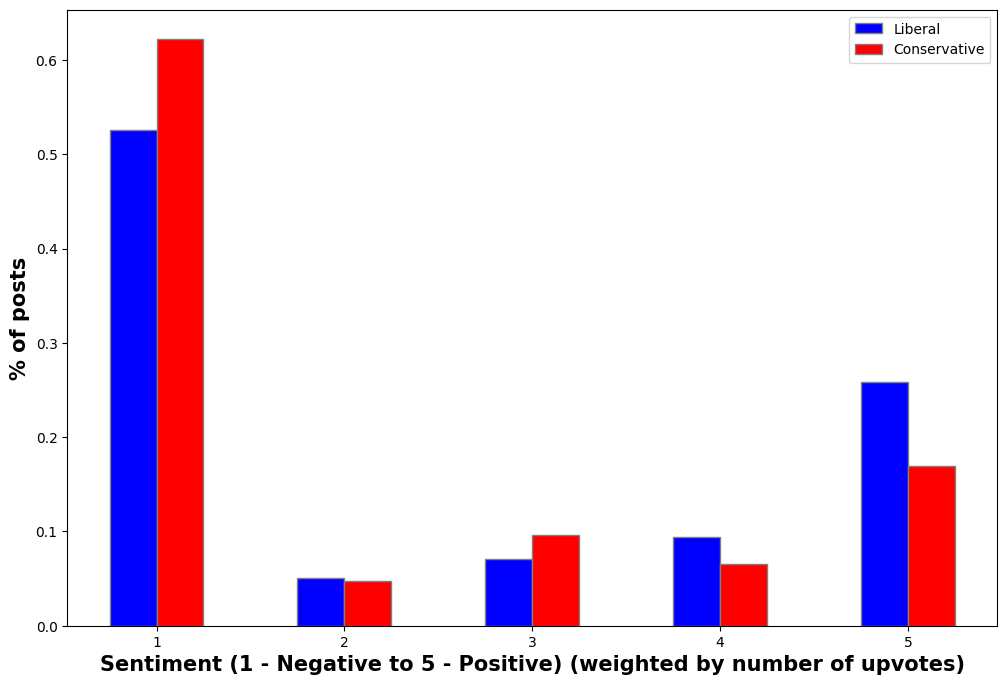

In [10]:
sentiment_lib_weighted = [0,0,0,0,0]
sentiment_cons_weighted = [0,0,0,0,0]
for i in range(len(df)):
    post = df.iloc[i]
    if post["Political Lean"] == "Liberal":
        sentiment_lib_weighted[post["Sentiment"]-1] += post["Score"]
    if post["Political Lean"] == "Conservative":
        sentiment_cons_weighted[post["Sentiment"]-1] += post["Score"]

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis([sentiment_lib_weighted, sentiment_cons_weighted])}")

sentiment_lib_weighted = sentiment_lib_weighted / sum(sentiment_lib_weighted)
sentiment_cons_weighted = sentiment_cons_weighted / sum(sentiment_cons_weighted)

barWidth = 0.25
fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(sentiments_lib_cat)) 
br2 = [x + barWidth for x in br1] 

plt.bar(br1, sentiment_lib_weighted, color ='b', width = barWidth, 
        edgecolor ='grey', label ='Liberal') 
plt.bar(br2, sentiment_cons_weighted, color ='r', width = barWidth, 
        edgecolor ='grey', label ='Conservative')

plt.xlabel('Sentiment (1 - Negative to 5 - Positive) (weighted by number of upvotes)', fontweight ='bold', fontsize = 15) 
plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
plt.xticks([r + barWidth/2 for r in range(len(sentiment_lib_weighted))], 
        ['1', '2', '3', '4', '5'])

plt.legend()
plt.show()  

# Sentiments per topic

In [11]:
df = pd.read_csv("data/reddit_posts_sentiment.csv")

In [12]:
df_topics = pd.read_csv("data/most_common_topic.csv")
df_sentiment_topics = pd.concat([df_topics, df["Sentiment"].rename("Sentiment")], axis=1)

In [13]:
df_sentiment_topics.columns

Index(['title', 'Political Lean', 'Score', 'Subreddit', 'Num of Comments',
       'selftext', 'Date Created', 'most_common_topic', 'Sentiment'],
      dtype='object')

In [14]:
#Topic to analyse:
topic = 0

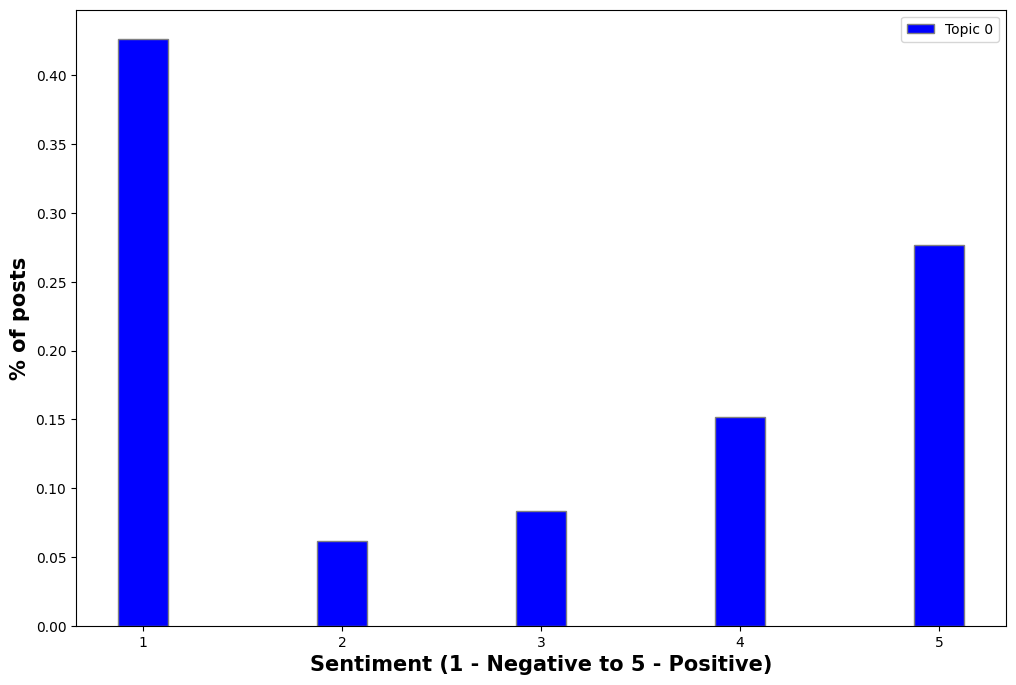

In [15]:
df_topic = df_sentiment_topics[df_sentiment_topics["most_common_topic"] == topic]
sentiments_topic_cat = df_topic.groupby("Sentiment").size().to_list()

sentiments_topic_cat[:] = [x / len(df_topic) for x in sentiments_topic_cat]
fig = plt.subplots(figsize =(12, 8))

br1 = np.arange(len(sentiments_topic_cat)) 

plt.bar(br1, sentiments_topic_cat, color ='b', width = barWidth, 
        edgecolor ='grey', label =f'Topic {topic}') 

plt.xlabel('Sentiment (1 - Negative to 5 - Positive)', fontweight ='bold', fontsize = 15) 
plt.ylabel('% of posts', fontweight ='bold', fontsize = 15) 
plt.xticks([r for r in range(len(sentiments_topic_cat))], 
        ['1', '2', '3', '4', '5'])

plt.legend()
plt.show()  

# Sentiment statistics

In [16]:
# Sentiments per subreddit (not-weighted)
list_of_subreddits = set(df["Subreddit"].to_list())
distributions = []
subreddit_averages = {}
for subreddit in list_of_subreddits:
    num_sub_posts = df.groupby("Subreddit").size()[subreddit]
    sub_distribution = df[df["Subreddit"] == subreddit].groupby(by="Sentiment").size().to_list()
    distributions.append(sub_distribution)
    subreddit_averages[subreddit] = sum((rating + 1) * count for rating, count in enumerate(sub_distribution)) / num_sub_posts

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis(distributions)}")

# Print the subreddits per average of sentiments
subreddit_averages = dict(sorted(subreddit_averages.items(), reverse=True, key=lambda item: item[1]))
print(subreddit_averages)

After performing chi2 analysis, we find a p-value of 5.6384970863131954e-61
{'Communist': np.float64(3.0735632183908046), 'socialism': np.float64(2.8697916666666665), 'SocialDemocracy': np.float64(2.8070866141732282), 'alltheleft': np.float64(2.791457286432161), 'anarchocapitalism': np.float64(2.668711656441718), 'DemocraticSocialism': np.float64(2.6465753424657534), 'feminisms': np.float64(2.6324324324324326), 'Capitalism': np.float64(2.5979247730220494), 'democrats': np.float64(2.5633001422475106), 'progressive': np.float64(2.3189542483660133), 'republicans': np.float64(2.3156532988357053), 'Libertarian': np.float64(2.3100263852242744), 'conservatives': np.float64(2.2698209718670075), 'Liberal': np.float64(2.0522696011004125)}


In [17]:
# Sentiments per subreddit (weighted)
list_of_subreddits = set(df["Subreddit"].to_list())

distributions = []
subreddit_averages = {}

for subreddit in list_of_subreddits:
    sentiment_sub_weighted = [0,0,0,0,0]

    subreddit_posts = df[df["Subreddit"] == subreddit]
    for i in range(len(subreddit_posts)):
        post = subreddit_posts.iloc[i]
        sentiment_sub_weighted[post["Sentiment"]-1] += post["Score"]

    distributions.append(sentiment_sub_weighted)
    subreddit_averages[subreddit] = sum((rating + 1) * count for rating, count in enumerate(sentiment_sub_weighted)) / sum(sentiment_sub_weighted)

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis(distributions)}")

# Print the subreddits per average of sentiments
subreddit_averages = dict(sorted(subreddit_averages.items(), reverse=True, key=lambda item: item[1]))
print(subreddit_averages)

After performing chi2 analysis, we find a p-value of 0.0
{'alltheleft': np.float64(3.057951528354551), 'Communist': np.float64(3.0411051212938007), 'socialism': np.float64(2.915966594188575), 'SocialDemocracy': np.float64(2.887926350739511), 'anarchocapitalism': np.float64(2.5565068493150687), 'DemocraticSocialism': np.float64(2.551495991134867), 'conservatives': np.float64(2.506518457527103), 'republicans': np.float64(2.4931078845800405), 'Capitalism': np.float64(2.456927794814608), 'democrats': np.float64(2.341170520329982), 'feminisms': np.float64(2.2890533573710345), 'progressive': np.float64(2.104102744460749), 'Liberal': np.float64(1.7293219384544039), 'Libertarian': np.float64(1.6403084714548803)}


In [21]:
# Sentiments per topic (not-weighted)
list_of_topics = set(df_sentiment_topics["most_common_topic"].to_list())

distributions = []
topic_averages = {}
for topic in list_of_topics:
    topic_sub_weighted = [0,0,0,0,0]

    topic_posts = df_sentiment_topics[df_sentiment_topics["most_common_topic"] == topic]
    for i in range(len(topic_posts)):
        post = topic_posts.iloc[i]
        topic_sub_weighted[post["Sentiment"]-1] += 1

    distributions.append(topic_sub_weighted)
    topic_averages[topic] = sum((rating + 1) * count for rating, count in enumerate(topic_sub_weighted)) / sum(topic_sub_weighted)

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis(distributions)}")

# Print the subreddits per average of sentiments
topic_averages = dict(sorted(topic_averages.items(), reverse=True, key=lambda item: item[1]))
print(topic_averages)

After performing chi2 analysis, we find a p-value of 1.492637616116972e-144
{45: 4.304347826086956, 30: 4.130434782608695, 46: 3.8823529411764706, 37: 3.869565217391304, 27: 3.764705882352941, 48: 3.4166666666666665, 39: 3.3043478260869565, 43: 3.25, 41: 3.16, 4: 3.1396508728179553, 10: 3.1043478260869564, 25: 2.9, 12: 2.885135135135135, 34: 2.823529411764706, 0: 2.7919096209912535, 32: 2.7586206896551726, 2: 2.727272727272727, 11: 2.68075117370892, 15: 2.680672268907563, 3: 2.6707317073170733, 28: 2.6666666666666665, 13: 2.608433734939759, 33: 2.6, 36: 2.56, 7: 2.556338028169014, 22: 2.5555555555555554, 29: 2.4857142857142858, 20: 2.4583333333333335, 6: 2.412, 18: 2.3835616438356166, 8: 2.3622250970245795, 31: 2.361111111111111, 42: 2.3181818181818183, 23: 2.295918367346939, 35: 2.2903225806451615, 21: 2.282608695652174, 17: 2.2711864406779663, 16: 2.2637362637362637, 26: 2.246913580246914, 38: 2.230769230769231, 47: 2.2222222222222223, 24: 2.086021505376344, 1: 2.0775401069518717, 44

In [ ]:
# Sentiments per topic (weighted)
list_of_topics = set(df_sentiment_topics["most_common_topic"].to_list())

distributions = []
topic_averages = {}
for topic in list_of_topics:
    topic_sub_weighted = [0,0,0,0,0]

    topic_posts = df_sentiment_topics[df_sentiment_topics["most_common_topic"] == topic]
    for i in range(len(topic_posts)):
        post = topic_posts.iloc[i]
        topic_sub_weighted[post["Sentiment"]-1] += post["Score"]

    distributions.append(topic_sub_weighted)
    topic_averages[topic] = sum((rating + 1) * count for rating, count in enumerate(topic_sub_weighted)) / sum(topic_sub_weighted)

print(f"After performing chi2 analysis, we find a p-value of {chisquare_analysis(distributions)}")

# Print the subreddits per average of sentiments
topic_averages = dict(sorted(topic_averages.items(), reverse=True, key=lambda item: item[1]))
print(topic_averages)